# HE2 Semana 06: Segmentación de Clientes con PCA y Clustering

## Objetivos de aprendizaje

1. Aplicar **PCA** para reducir dimensionalidad y construir un **biplot** interpretable.
2. Implementar tres algoritmos de clustering: **K-Means**, **Clustering Aglomerativo** y **DBSCAN**.
3. Realizar **tuneo de hiperparámetros** usando la métrica **Silhouette Score**.
4. Comparar los métodos y seleccionar la mejor segmentación.
5. Hacer **post-procesamiento** para perfilar e interpretar los segmentos resultantes.

## Dataset

**Wholesale Customers Data** (UCI ML Repository)  
Registros de gasto anual de ~440 clientes de un distribuidor mayorista en Portugal, distribuidos en 6 categorías de producto y 2 variables categóricas (canal y región).

| Variable | Descripción |
|---|---|
| Channel | 1 = Hotel/Restaurante/Café, 2 = Retail |
| Region | 1 = Lisboa, 2 = Oporto, 3 = Otra |
| Fresh | Gasto anual en productos frescos |
| Milk | Gasto anual en lácteos |
| Grocery | Gasto anual en abarrotes |
| Frozen | Gasto anual en congelados |
| Detergents_Paper | Gasto anual en detergentes y papel |
| Delicassen | Gasto anual en delicatessen |

---
## 0. Configuración e imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Preprocessing & PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluación
from sklearn.metrics import silhouette_score, silhouette_samples

# Dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
print("Imports cargados correctamente.")

Imports cargados correctamente.


In [2]:
# ── Constantes de configuración ─────────────────────────────────────
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00292/Wholesale%20customers%20data.csv"
)
RANDOM_STATE = 1999
K_RANGE = range(2, 11)          # rango de k para K-Means y Aglomerativo
DBSCAN_EPS_RANGE = np.arange(0.3, 2.1, 0.1)
DBSCAN_MIN_SAMPLES_RANGE = [3, 5, 7, 10]
N_PCA_COMPONENTS = 2            # componentes para visualización
FIGSIZE_WIDE = (14, 5)
FIGSIZE_SQUARE = (8, 6)

---
## 1. Carga y exploración de datos

In [3]:
df_raw = pd.read_csv(DATA_URL)
print(f"Shape original: {df_raw.shape}")
display(df_raw.head())

Shape original: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
print("\nInfo del dataset:")
print(df_raw.info())
print(f"\nValores nulos por columna:\n{df_raw.isna().sum()}")
print(f"\nFilas duplicadas: {df_raw.duplicated().sum()}")


Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Valores nulos por columna:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Filas duplicadas: 0


In [5]:
display(df_raw.describe().round(1))

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


### 1.1 Selección de features para segmentación

Usaremos las **6 variables de gasto** como features de segmentación. Las columnas `Channel` y `Region` se guardan aparte para validar después.

In [6]:
SPENDING_COLS = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
META_COLS = ["Channel", "Region"]

X = df_raw[SPENDING_COLS].copy()
meta = df_raw[META_COLS].copy()

print(f"Features de segmentación: {SPENDING_COLS}")
print(f"Shape X: {X.shape}")

# Validación
if X.isna().sum().sum() > 0:
    raise ValueError("Hay valores nulos en X.")
print("Sin valores nulos en features.")

Features de segmentación: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Shape X: (440, 6)
Sin valores nulos en features.


### 1.2 Distribución de features

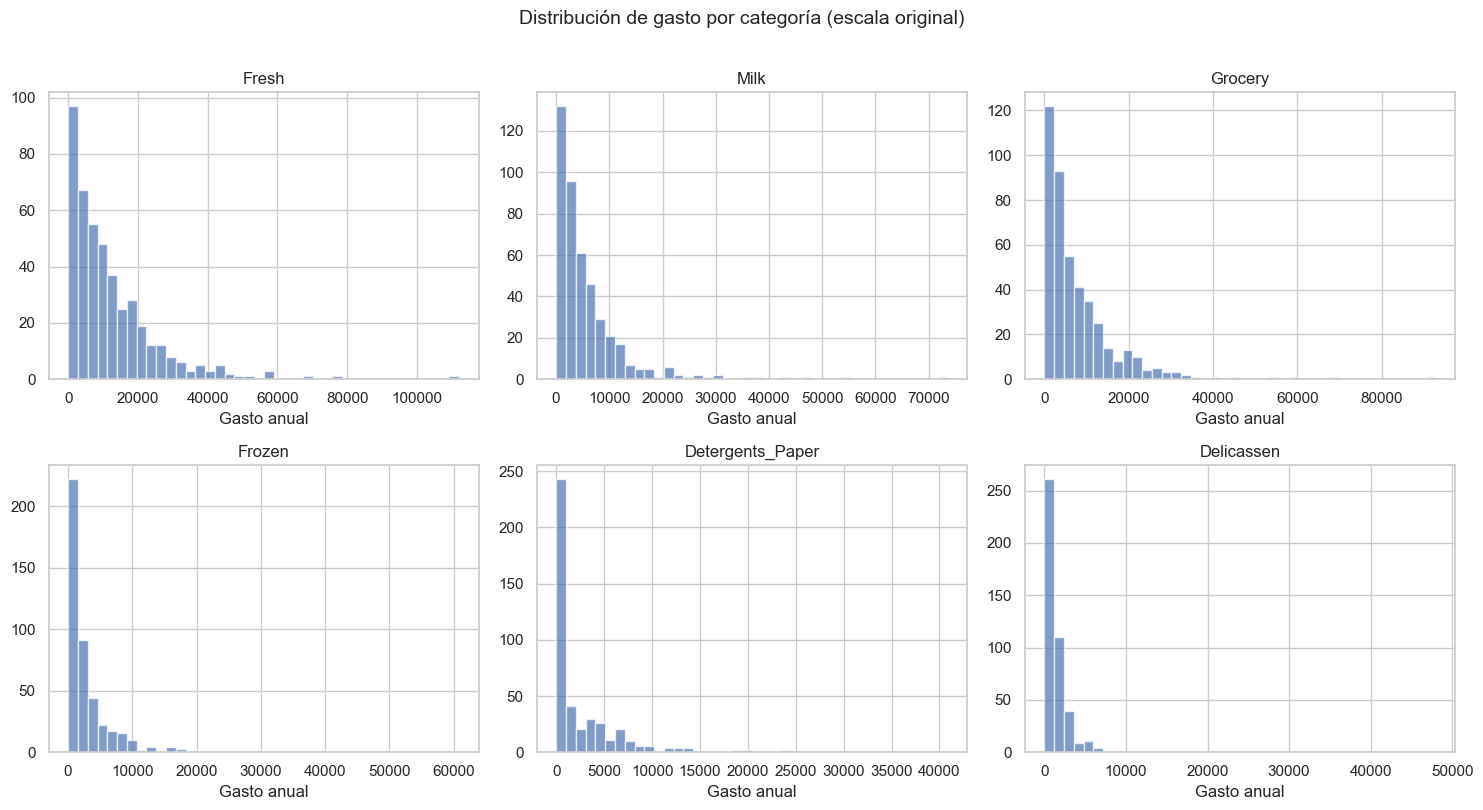

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), SPENDING_COLS):
    ax.hist(X[col], bins=40, edgecolor="white", alpha=0.7)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Gasto anual")
fig.suptitle("Distribución de gasto por categoría (escala original)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

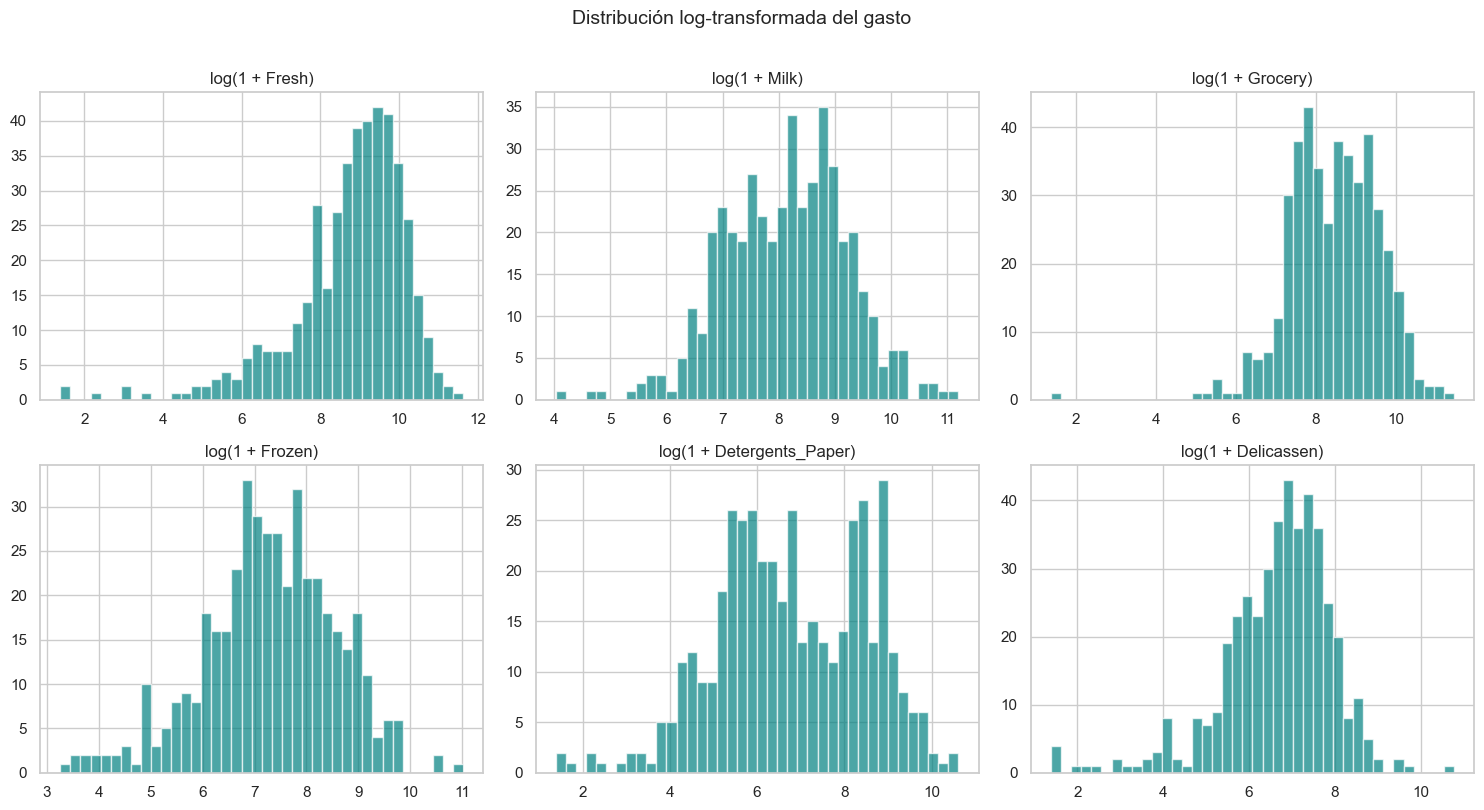

In [8]:
# Transformación logarítmica para visualizar mejor
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), SPENDING_COLS):
    ax.hist(np.log1p(X[col]), bins=40, edgecolor="white", alpha=0.7, color="teal")
    ax.set_title(f"log(1 + {col})", fontsize=12)
fig.suptitle("Distribución log-transformada del gasto", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

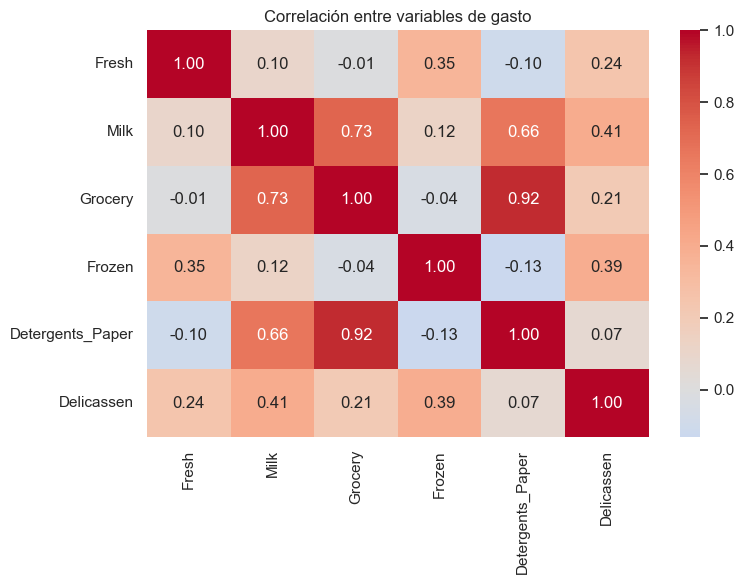

In [9]:
# Matriz de correlación
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables de gasto")
plt.tight_layout()
plt.show()

---
## 2. Preprocesamiento

Aplicamos **log-transform** para reducir el sesgo de las distribuciones y luego **estandarizamos** (media 0, varianza 1). Esto es crítico para PCA y algoritmos basados en distancia.

In [10]:
# Log-transform para reducir skewness
X_log = np.log1p(X)

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=SPENDING_COLS, index=X.index)

print("Estadísticas después de log + StandardScaler:")
display(X_scaled.describe().round(2))

Estadísticas después de log + StandardScaler:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18


---
## 3. Análisis de Componentes Principales (PCA)

### 3.1 Varianza explicada

In [11]:
# PCA con todos los componentes para analizar varianza
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, (v, vc) in enumerate(zip(var_exp, var_cum), 1):
    print(f"  PC{i}: {v:.4f}  (acumulada: {vc:.4f})")

Varianza explicada por componente:
  PC1: 0.4408  (acumulada: 0.4408)
  PC2: 0.2719  (acumulada: 0.7127)
  PC3: 0.1070  (acumulada: 0.8197)
  PC4: 0.1010  (acumulada: 0.9207)
  PC5: 0.0488  (acumulada: 0.9695)
  PC6: 0.0305  (acumulada: 1.0000)


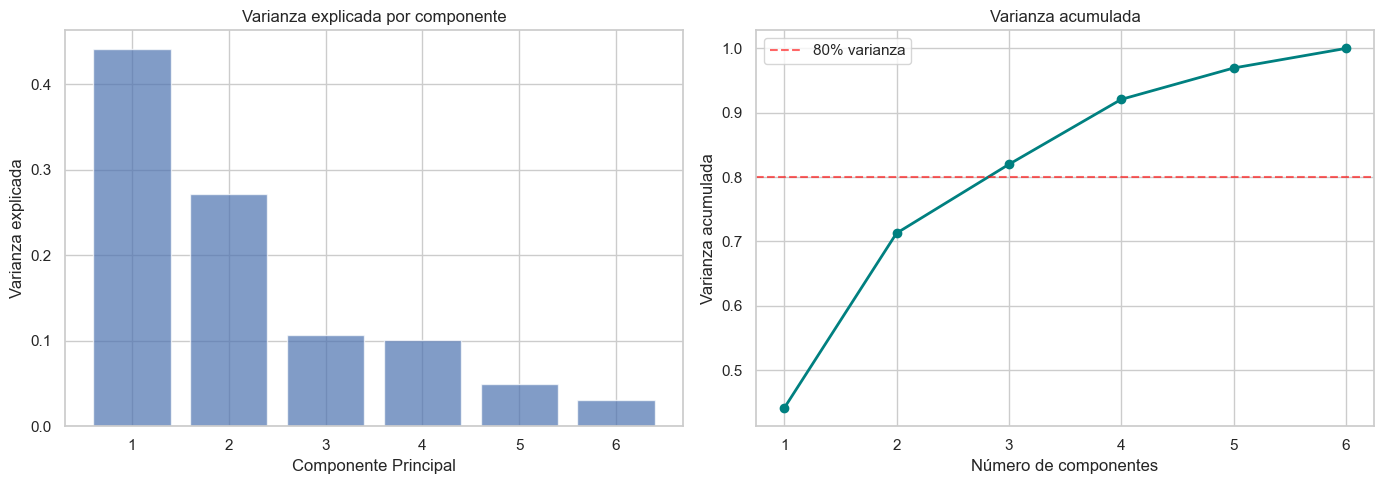

In [12]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Varianza individual
axes[0].bar(range(1, len(var_exp) + 1), var_exp, alpha=0.7, edgecolor="white")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_xticks(range(1, len(var_exp) + 1))

# Varianza acumulada
axes[1].plot(range(1, len(var_cum) + 1), var_cum, "o-", color="teal", linewidth=2)
axes[1].axhline(y=0.80, color="red", linestyle="--", alpha=0.6, label="80% varianza")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza acumulada")
axes[1].set_xticks(range(1, len(var_cum) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Proyección a 2D y Biplot

In [13]:
# PCA con 2 componentes
pca_2d = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Varianza explicada por PC1 + PC2: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"Shape proyección: {X_pca.shape}")

Varianza explicada por PC1 + PC2: 0.7127
Shape proyección: (440, 2)


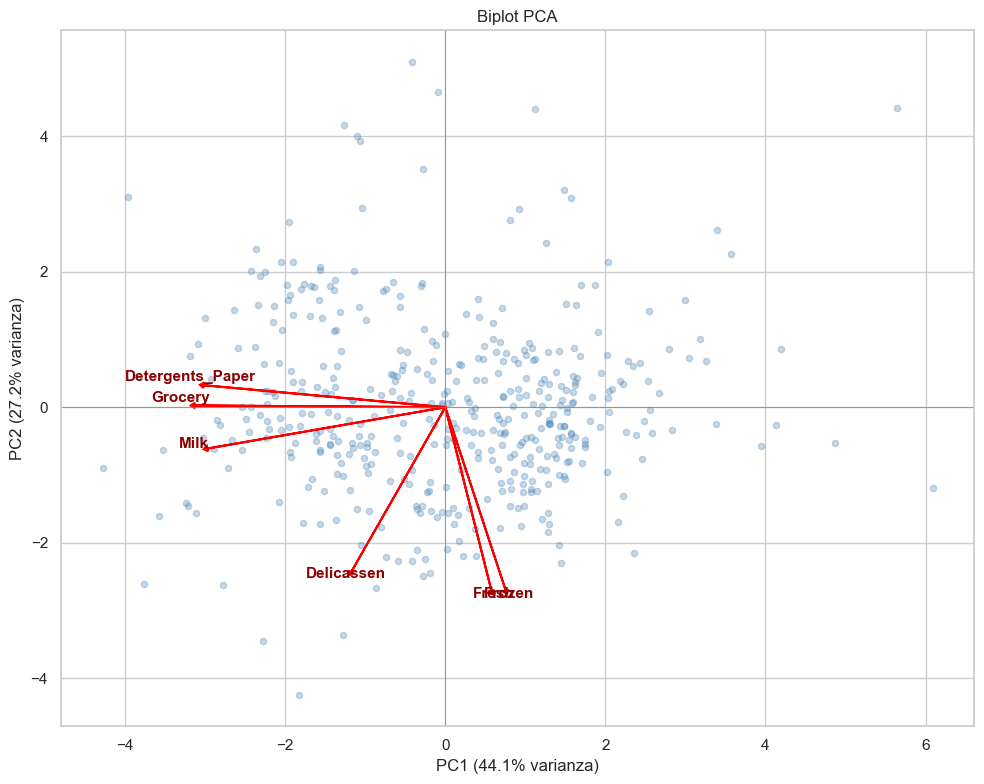

In [14]:
def biplot(score, coeff, labels, ax=None):
    """Genera un biplot de PCA: scores (puntos) + loadings (flechas)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter de observaciones
    ax.scatter(score[:, 0], score[:, 1], alpha=0.3, s=20, c="steelblue")

    # Flechas de loadings
    scale = np.abs(score).max(axis=0)  # escalar flechas
    for i, label in enumerate(labels):
        ax.arrow(
            0, 0,
            coeff[i, 0] * scale[0] * 0.9,
            coeff[i, 1] * scale[1] * 0.9,
            head_width=0.08, head_length=0.05,
            fc="red", ec="red", linewidth=1.5
        )
        ax.text(
            coeff[i, 0] * scale[0] * 0.95,
            coeff[i, 1] * scale[1] * 0.95,
            label, fontsize=11, color="darkred", fontweight="bold",
            ha="center", va="bottom"
        )

    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)")
    ax.set_title("Biplot PCA")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    return ax


fig, ax = plt.subplots(figsize=(10, 8))
biplot(X_pca, pca_2d.components_.T, SPENDING_COLS, ax=ax)
plt.tight_layout()
plt.show()

**Interpretación del Biplot:**
- Las **flechas** indican la dirección y magnitud de cada variable original en el espacio de los 2 primeros componentes.
- Flechas que apuntan en la misma dirección sugieren alta correlación positiva.
- `Grocery`, `Milk` y `Detergents_Paper` tienden a correlacionarse (clientes retail).
- `Fresh`, `Frozen` y `Delicassen` conforman otro grupo (clientes horeca).

---
## 4. Clustering

### Función auxiliar de evaluación

In [15]:
def evaluate_clustering(X, labels, method_name):
    """Calcula métricas de clustering y retorna un dict resumen."""
    n_clusters = len(set(labels) - {-1})  # excluir ruido (-1)
    n_noise = (labels == -1).sum()

    # Silhouette solo si hay al menos 2 clusters y no todo es ruido
    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan

    return {
        "method": method_name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
    }

### 4.1 K-Means

#### 4.1.1 Método del codo + Silhouette para seleccionar *k*

In [16]:
inertias = []
sil_scores_km = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X_scaled, labels_k))

best_k_km = list(K_RANGE)[np.argmax(sil_scores_km)]
print(f"Mejor k (K-Means) por Silhouette: {best_k_km} (score = {max(sil_scores_km):.4f})")

Mejor k (K-Means) por Silhouette: 2 (score = 0.2903)


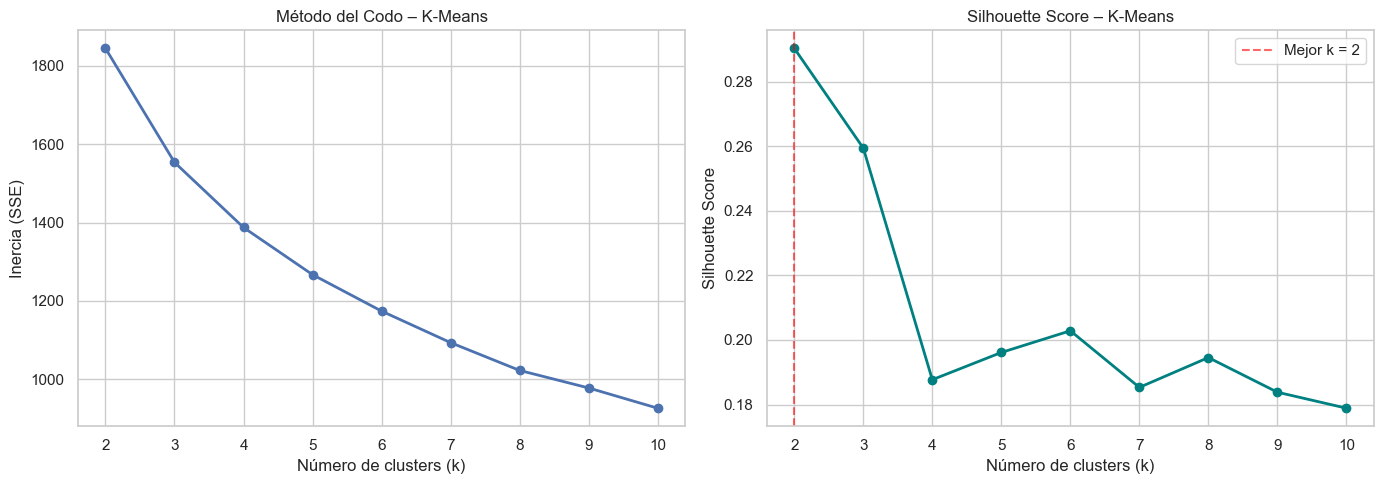

In [17]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Método del codo
axes[0].plot(list(K_RANGE), inertias, "o-", linewidth=2)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (SSE)")
axes[0].set_title("Método del Codo – K-Means")

# Silhouette vs k
axes[1].plot(list(K_RANGE), sil_scores_km, "o-", linewidth=2, color="teal")
axes[1].axvline(x=best_k_km, color="red", linestyle="--", alpha=0.6, label=f"Mejor k = {best_k_km}")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score – K-Means")
axes[1].legend()

plt.tight_layout()
plt.show()

#### 4.1.2 Modelo final K-Means

In [18]:
km_final = KMeans(n_clusters=best_k_km, n_init=10, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_scaled)

res_km = evaluate_clustering(X_scaled.values, labels_km, f"K-Means (k={best_k_km})")
print(res_km)

{'method': 'K-Means (k=2)', 'n_clusters': 2, 'n_noise': np.int64(0), 'silhouette': np.float64(0.2903)}


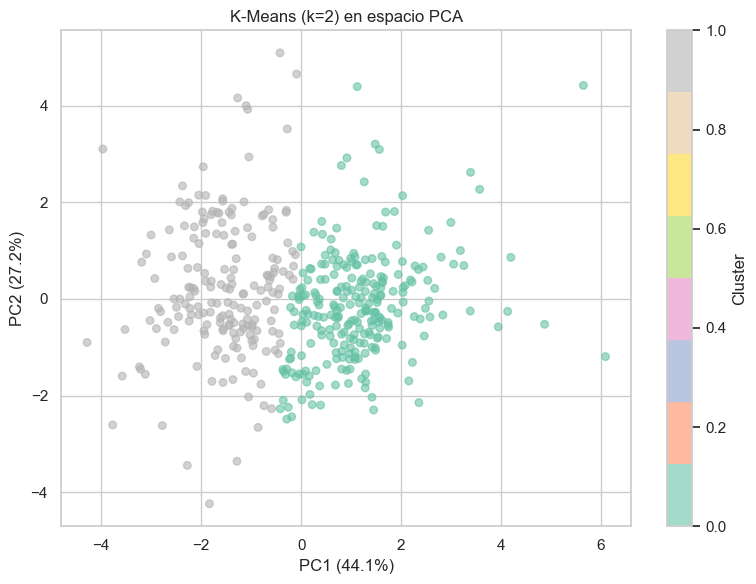

In [19]:
# Visualización en espacio PCA
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="Set2", alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"K-Means (k={best_k_km}) en espacio PCA")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

#### 4.1.3 Silhouette Plot detallado

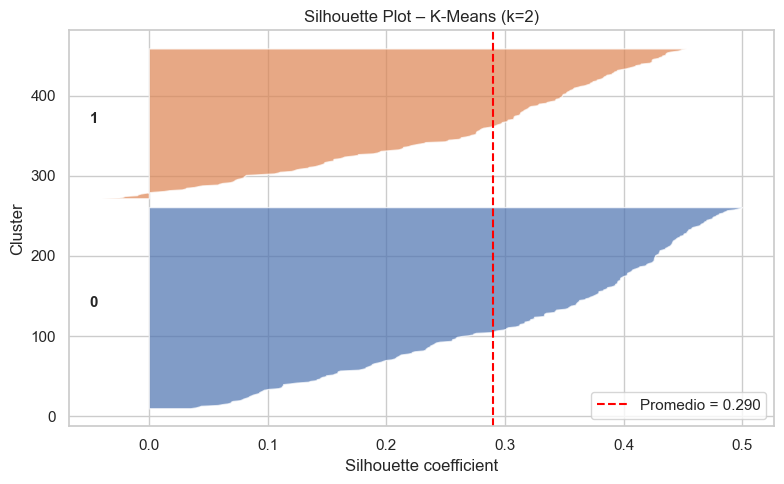

In [20]:
def plot_silhouette(X, labels, title):
    """Genera un silhouette plot por cluster."""
    mask = labels != -1
    X_clean = X[mask]
    labels_clean = labels[mask]

    sil_avg = silhouette_score(X_clean, labels_clean)
    sample_sil = silhouette_samples(X_clean, labels_clean)
    n_clusters = len(set(labels_clean))

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10

    for i in sorted(set(labels_clean)):
        cluster_sil = np.sort(sample_sil[labels_clean == i])
        size_i = cluster_sil.shape[0]
        y_upper = y_lower + size_i

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=11, fontweight="bold")
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5,
               label=f"Promedio = {sil_avg:.3f}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


plot_silhouette(X_scaled.values, labels_km, f"Silhouette Plot – K-Means (k={best_k_km})")

### 4.2 Clustering Aglomerativo (Jerárquico)

#### 4.2.1 Dendrograma

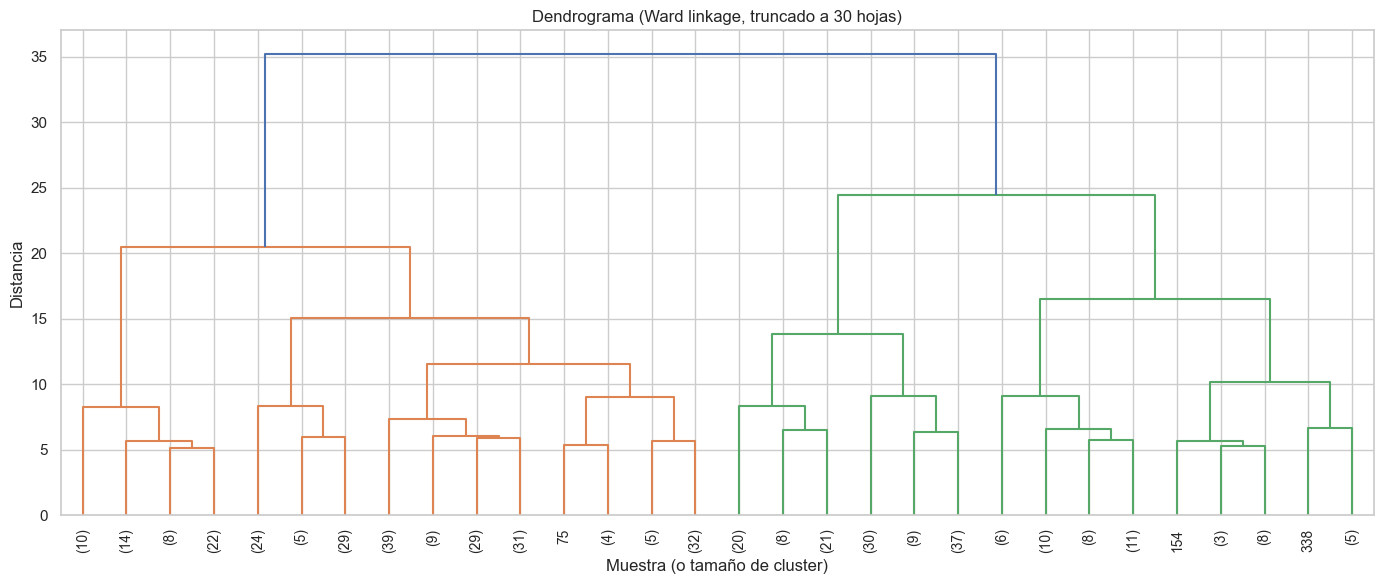

In [21]:
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=10,
    ax=ax,
)
ax.set_title("Dendrograma (Ward linkage, truncado a 30 hojas)")
ax.set_xlabel("Muestra (o tamaño de cluster)")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

#### 4.2.2 Tuneo de k por Silhouette

In [22]:
sil_scores_agg = []

for k in K_RANGE:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_agg_k = agg.fit_predict(X_scaled)
    sil_scores_agg.append(silhouette_score(X_scaled, labels_agg_k))

best_k_agg = list(K_RANGE)[np.argmax(sil_scores_agg)]
print(f"Mejor k (Aglomerativo) por Silhouette: {best_k_agg} (score = {max(sil_scores_agg):.4f})")

Mejor k (Aglomerativo) por Silhouette: 2 (score = 0.2585)


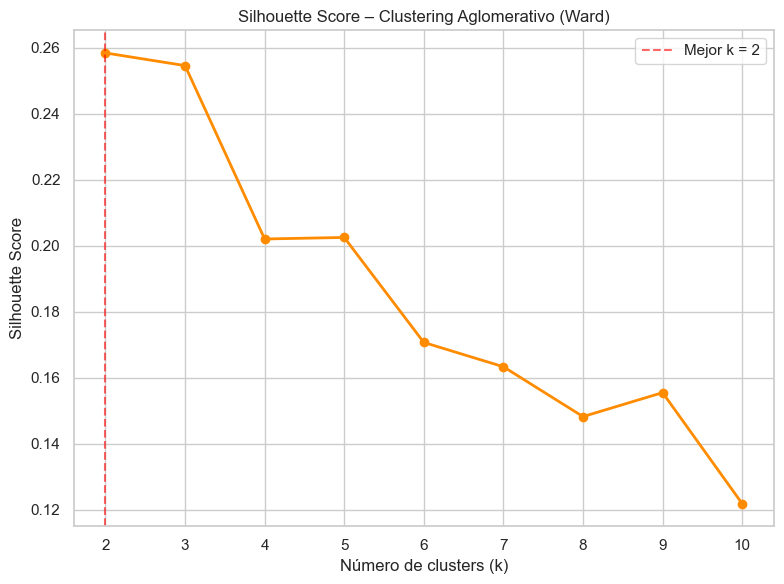

In [23]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
ax.plot(list(K_RANGE), sil_scores_agg, "o-", linewidth=2, color="darkorange")
ax.axvline(x=best_k_agg, color="red", linestyle="--", alpha=0.6, label=f"Mejor k = {best_k_agg}")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score – Clustering Aglomerativo (Ward)")
ax.legend()
plt.tight_layout()
plt.show()

#### 4.2.3 Modelo final Aglomerativo

In [24]:
agg_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward")
labels_agg = agg_final.fit_predict(X_scaled)

res_agg = evaluate_clustering(X_scaled.values, labels_agg, f"Aglomerativo (k={best_k_agg})")
print(res_agg)

{'method': 'Aglomerativo (k=2)', 'n_clusters': 2, 'n_noise': np.int64(0), 'silhouette': np.float64(0.2585)}


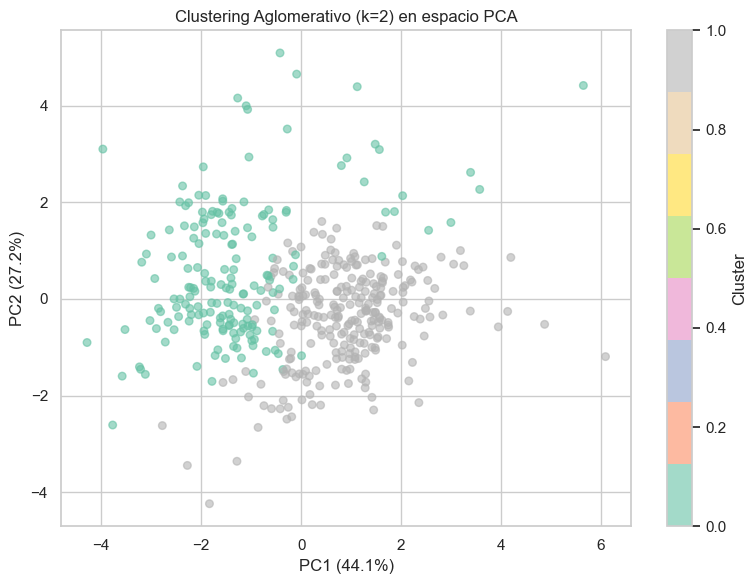

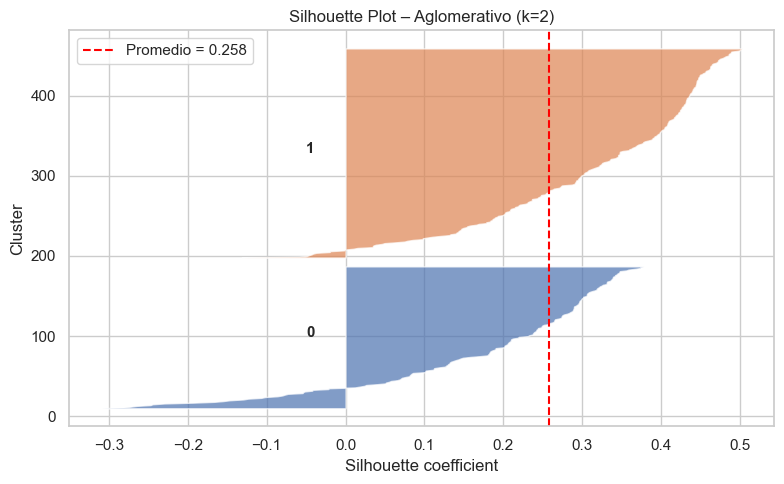

In [25]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap="Set2", alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"Clustering Aglomerativo (k={best_k_agg}) en espacio PCA")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

plot_silhouette(X_scaled.values, labels_agg, f"Silhouette Plot – Aglomerativo (k={best_k_agg})")

### 4.3 DBSCAN

#### 4.3.1 Grid search sobre eps y min_samples

In [26]:
dbscan_results = []

for eps in DBSCAN_EPS_RANGE:
    for min_samples in DBSCAN_MIN_SAMPLES_RANGE:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = db.fit_predict(X_scaled)

        n_clusters = len(set(labels_db) - {-1})
        n_noise = (labels_db == -1).sum()
        noise_pct = n_noise / len(labels_db) * 100

        # Silhouette solo si hay >=2 clusters y suficientes puntos no-ruido
        mask = labels_db != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = silhouette_score(X_scaled.values[mask], labels_db[mask])
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": round(eps, 2),
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": round(noise_pct, 1),
            "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
        })

df_dbscan = pd.DataFrame(dbscan_results)
print("Top 10 configuraciones DBSCAN por Silhouette:")
display(df_dbscan.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(10))

Top 10 configuraciones DBSCAN por Silhouette:


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
4,0.4,3,2,433,98.4,0.7297
14,0.6,7,2,416,94.5,0.6970
23,0.8,10,2,334,75.9,0.5372
18,0.7,7,3,393,89.3,0.5086
27,0.9,10,2,248,56.4,0.4613
8,0.5,3,8,396,90.0,0.4175
48,1.5,3,2,35,8.0,0.3973
52,1.6,3,2,32,7.3,0.3952
17,0.7,5,4,343,78.0,0.3640
13,0.6,5,7,385,87.5,0.3606


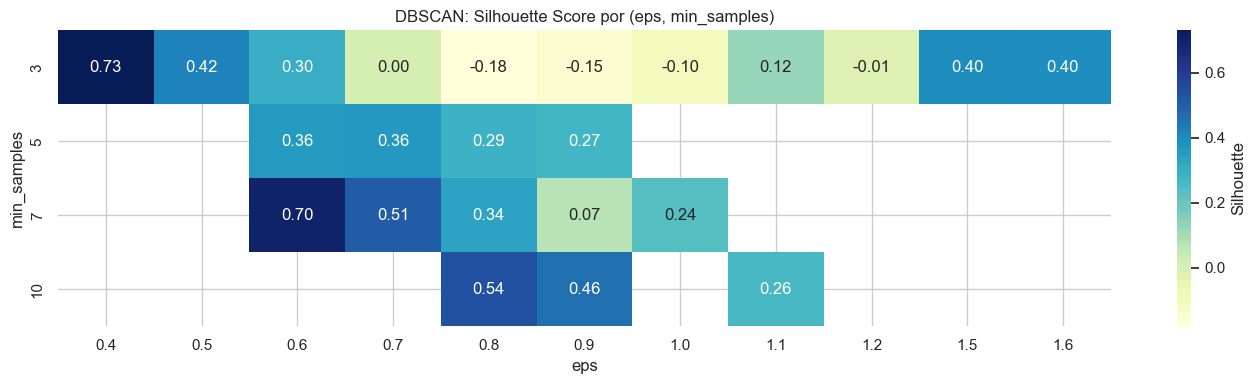

In [27]:
# Heatmap de Silhouette para DBSCAN
pivot = df_dbscan.pivot_table(index="min_samples", columns="eps", values="silhouette")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Silhouette"})
ax.set_title("DBSCAN: Silhouette Score por (eps, min_samples)")
ax.set_xlabel("eps")
ax.set_ylabel("min_samples")
plt.tight_layout()
plt.show()

#### 4.3.2 Modelo final DBSCAN

In [28]:
# Seleccionar mejor combinación (mayor silhouette, ruido < 30%)
df_valid = df_dbscan.dropna(subset=["silhouette"]).query("noise_pct < 30 and n_clusters >= 2")

if len(df_valid) > 0:
    best_db = df_valid.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = best_db["eps"]
    best_min_samples = int(best_db["min_samples"])
    print(f"Mejor DBSCAN: eps={best_eps}, min_samples={best_min_samples}")
    print(f"  Clusters: {int(best_db['n_clusters'])}, Ruido: {best_db['noise_pct']}%, Silhouette: {best_db['silhouette']}")
else:
    # Fallback: relajar restricción de ruido
    df_valid = df_dbscan.dropna(subset=["silhouette"]).query("n_clusters >= 2")
    best_db = df_valid.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = best_db["eps"]
    best_min_samples = int(best_db["min_samples"])
    print(f"Mejor DBSCAN (sin filtro de ruido): eps={best_eps}, min_samples={best_min_samples}")
    print(f"  Clusters: {int(best_db['n_clusters'])}, Ruido: {best_db['noise_pct']}%, Silhouette: {best_db['silhouette']}")

Mejor DBSCAN: eps=1.5, min_samples=3
  Clusters: 2, Ruido: 8.0%, Silhouette: 0.3973


In [29]:
db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = db_final.fit_predict(X_scaled)

res_db = evaluate_clustering(X_scaled.values, labels_db, f"DBSCAN (eps={best_eps}, ms={best_min_samples})")
print(res_db)

{'method': 'DBSCAN (eps=1.5, ms=3)', 'n_clusters': 2, 'n_noise': np.int64(35), 'silhouette': np.float64(0.3973)}


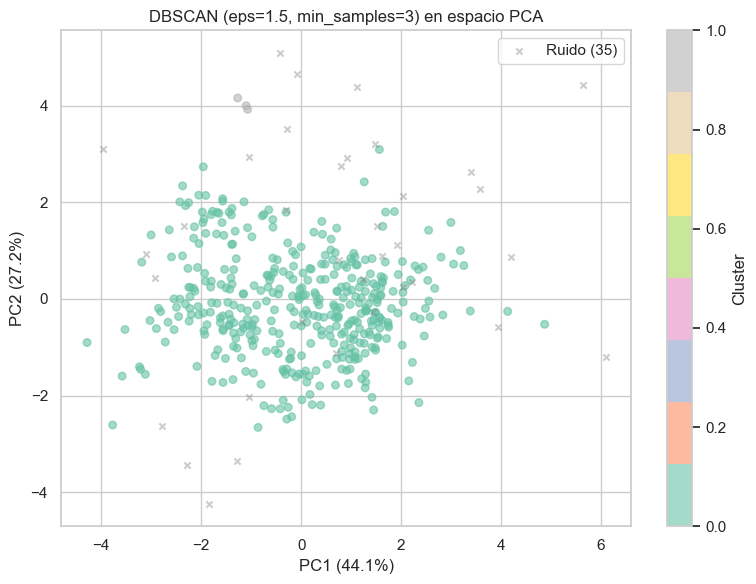

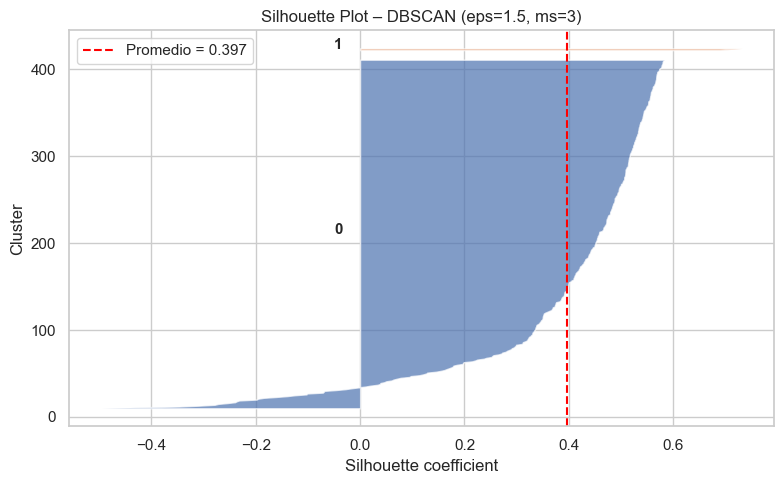

In [30]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
# -1 = ruido, se pinta en gris
colors = labels_db.copy().astype(float)
colors[labels_db == -1] = np.nan

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap="Set2", alpha=0.6, s=30)
# Puntos de ruido
noise_mask = labels_db == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
           c="grey", marker="x", alpha=0.4, s=20, label=f"Ruido ({noise_mask.sum()})")

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}) en espacio PCA")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

if res_db["n_clusters"] >= 2:
    plot_silhouette(X_scaled.values, labels_db,
                    f"Silhouette Plot – DBSCAN (eps={best_eps}, ms={best_min_samples})")

---
## 5. Comparación de métodos

In [31]:
comparison_df = pd.DataFrame([res_km, res_agg, res_db])
comparison_df = comparison_df.sort_values("silhouette", ascending=False)
display(comparison_df)

,method,n_clusters,n_noise,silhouette
2,"DBSCAN (eps=1.5, ms=3)",2,35,0.3973
0,K-Means (k=2),2,0,0.2903
1,Aglomerativo (k=2),2,0,0.2585


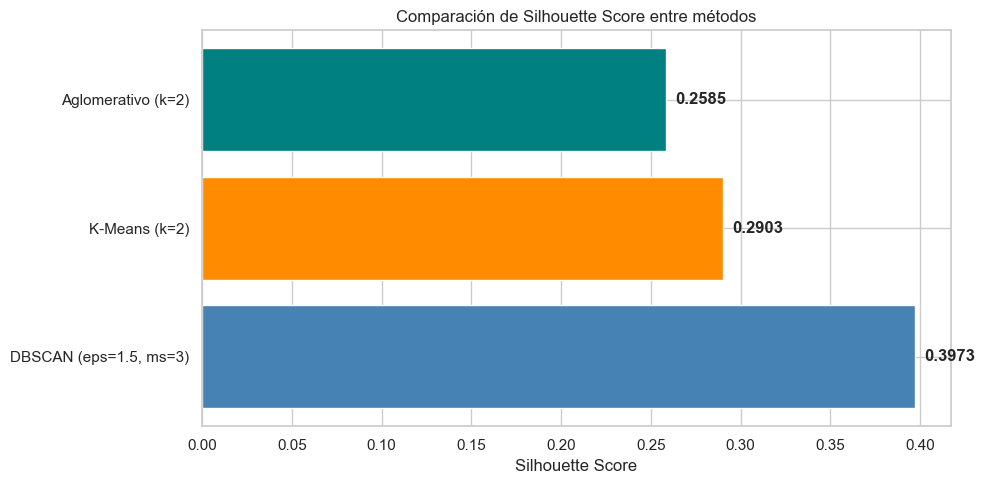

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(comparison_df["method"], comparison_df["silhouette"],
               color=["steelblue", "darkorange", "teal"], edgecolor="white")
ax.set_xlabel("Silhouette Score")
ax.set_title("Comparación de Silhouette Score entre métodos")
for bar, val in zip(bars, comparison_df["silhouette"]):
    if not np.isnan(val):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
# Seleccionar el mejor método
best_method = comparison_df.iloc[0]["method"]
print(f"\nMejor método por Silhouette: {best_method}")

# Asignar las etiquetas del mejor método
if "K-Means" in best_method:
    best_labels = labels_km
elif "Aglomerativo" in best_method:
    best_labels = labels_agg
else:
    best_labels = labels_db

print(f"Distribución de clusters: {pd.Series(best_labels).value_counts().sort_index().to_dict()}")


Mejor método por Silhouette: DBSCAN (eps=1.5, ms=3)
Distribución de clusters: {-1: 35, 0: 402, 1: 3}


---
## 6. Post-procesamiento: Perfilamiento de segmentos

### 6.1 Estadísticas descriptivas por segmento

In [34]:
df_segmented = X.copy()
df_segmented["Segment"] = best_labels
df_segmented["Channel"] = meta["Channel"].values
df_segmented["Region"] = meta["Region"].values

# Excluir ruido si aplica
df_segmented = df_segmented[df_segmented["Segment"] != -1].copy()

print(f"Registros por segmento:")
display(df_segmented["Segment"].value_counts().sort_index().to_frame("count"))

Registros por segmento:


,count
Segment,
0,402
1,3


In [35]:
# Media de gasto por segmento
segment_profile = df_segmented.groupby("Segment")[SPENDING_COLS].mean().round(0)
print("\nGasto medio por segmento (escala original):")
display(segment_profile)


Gasto medio por segmento (escala original):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Segment,,,,,,
0,11844.0,5675.0,7651.0,2894.0,2842.0,1372.0
1,52.0,2499.0,14263.0,127.0,4530.0,130.0


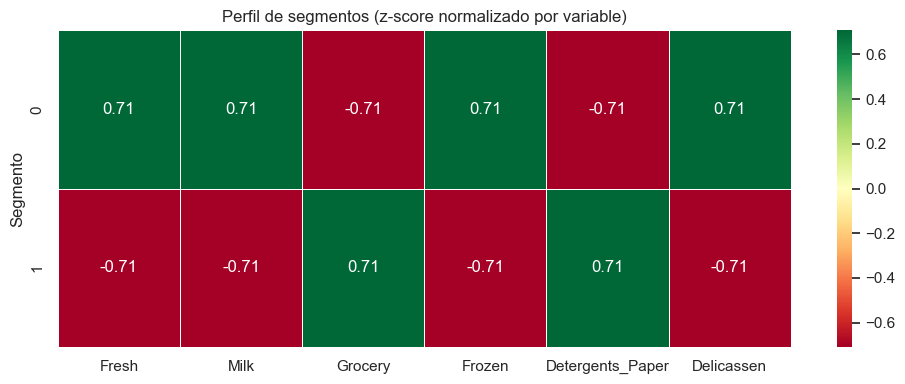

In [36]:
# Heatmap de perfiles normalizados (z-score por columna para comparar)
profile_normalized = segment_profile.apply(lambda col: (col - col.mean()) / col.std(), axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_normalized, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.5)
ax.set_title("Perfil de segmentos (z-score normalizado por variable)")
ax.set_ylabel("Segmento")
plt.tight_layout()
plt.show()

### 6.2 Composición de Canal y Región por segmento

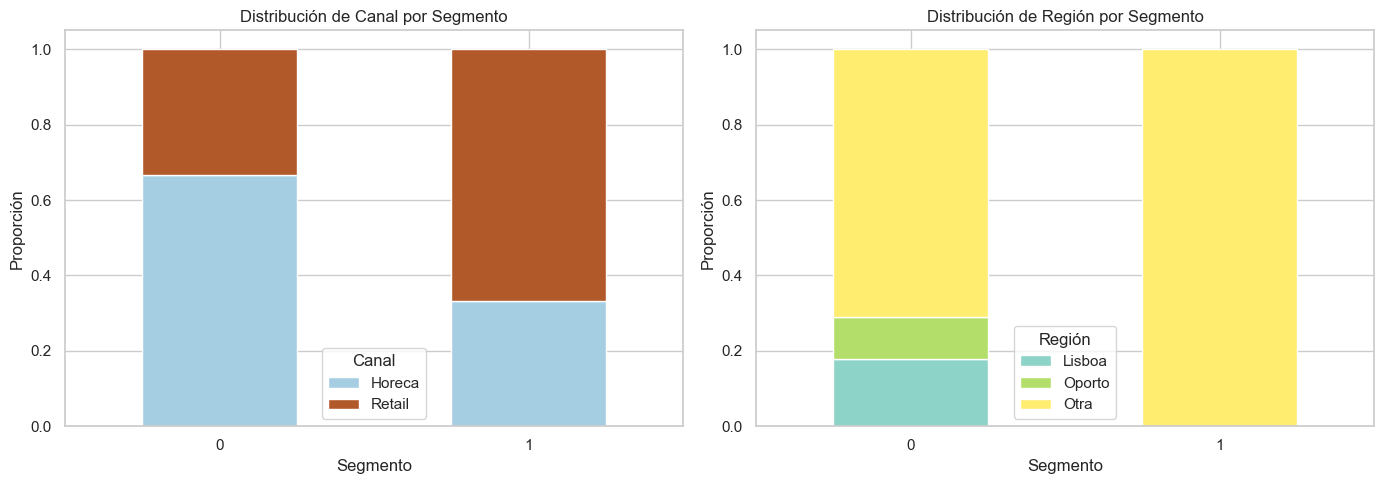

In [37]:
channel_map = {1: "Horeca", 2: "Retail"}
region_map = {1: "Lisboa", 2: "Oporto", 3: "Otra"}

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Canal
ct_channel = pd.crosstab(df_segmented["Segment"],
                          df_segmented["Channel"].map(channel_map), normalize="index")
ct_channel.plot(kind="bar", stacked=True, ax=axes[0], colormap="Paired", edgecolor="white")
axes[0].set_title("Distribución de Canal por Segmento")
axes[0].set_ylabel("Proporción")
axes[0].set_xlabel("Segmento")
axes[0].legend(title="Canal")
axes[0].tick_params(axis="x", rotation=0)

# Región
ct_region = pd.crosstab(df_segmented["Segment"],
                         df_segmented["Region"].map(region_map), normalize="index")
ct_region.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3", edgecolor="white")
axes[1].set_title("Distribución de Región por Segmento")
axes[1].set_ylabel("Proporción")
axes[1].set_xlabel("Segmento")
axes[1].legend(title="Región")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 6.3 Radar Chart por segmento

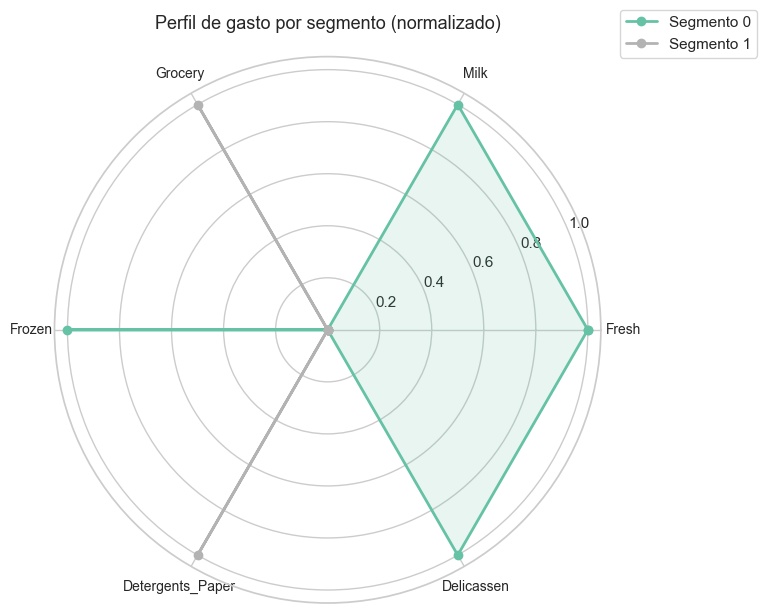

In [38]:
# Normalizar medias a [0, 1] para radar chart
profile_norm_01 = segment_profile.copy()
for col in SPENDING_COLS:
    min_val = segment_profile[col].min()
    max_val = segment_profile[col].max()
    if max_val > min_val:
        profile_norm_01[col] = (segment_profile[col] - min_val) / (max_val - min_val)
    else:
        profile_norm_01[col] = 0.5

n_segments = len(profile_norm_01)
angles = np.linspace(0, 2 * np.pi, len(SPENDING_COLS), endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
colors_radar = plt.cm.Set2(np.linspace(0, 1, n_segments))

for idx, (seg, row) in enumerate(profile_norm_01.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, "o-", linewidth=2, label=f"Segmento {seg}", color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(SPENDING_COLS, fontsize=10)
ax.set_title("Perfil de gasto por segmento (normalizado)", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

### 6.4 Boxplots por segmento

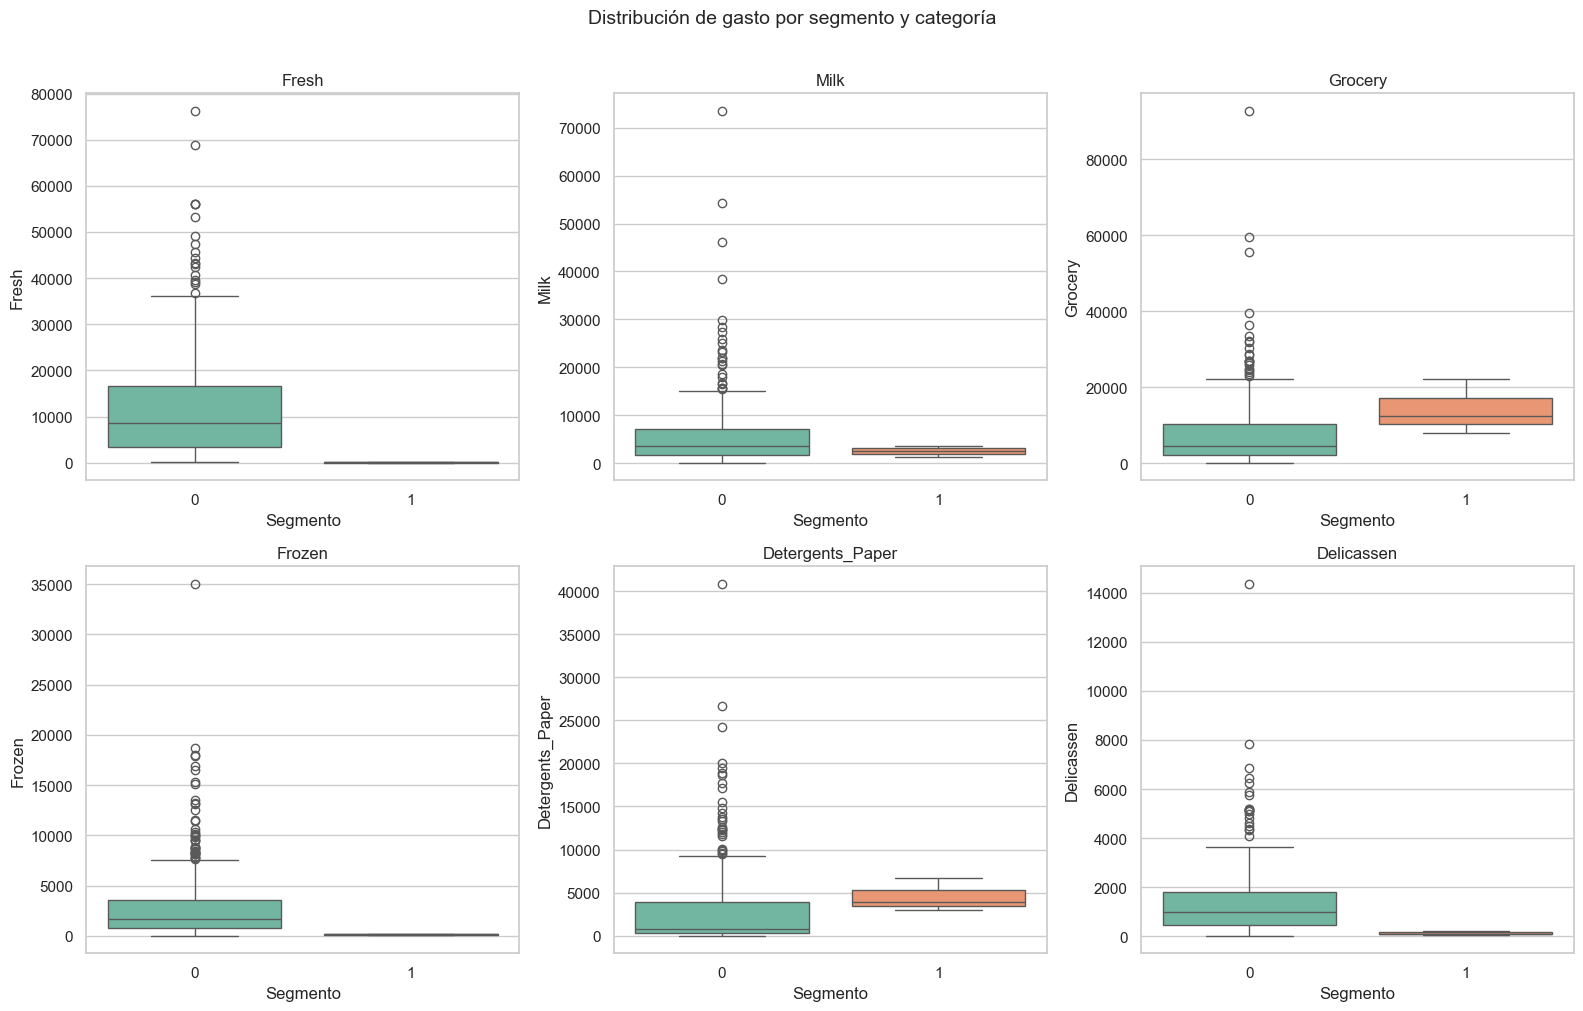

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.ravel(), SPENDING_COLS):
    sns.boxplot(data=df_segmented, x="Segment", y=col, ax=ax, palette="Set2")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Segmento")

fig.suptitle("Distribución de gasto por segmento y categoría", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.5 Interpretación y etiquetado de segmentos

In [40]:
print("=" * 70)
print("RESUMEN DE SEGMENTACIÓN")
print("=" * 70)

for seg in sorted(df_segmented["Segment"].unique()):
    seg_data = df_segmented[df_segmented["Segment"] == seg]
    n = len(seg_data)
    pct = n / len(df_segmented) * 100

    # Variable dominante (mayor gasto medio relativo al global)
    means = seg_data[SPENDING_COLS].mean()
    global_means = df_segmented[SPENDING_COLS].mean()
    ratio = (means / global_means).sort_values(ascending=False)

    # Composición de canal
    channel_dist = seg_data["Channel"].map(channel_map).value_counts(normalize=True)

    print(f"\n--- Segmento {seg} ({n} clientes, {pct:.1f}%) ---")
    print(f"  Categorías con mayor gasto relativo:")
    for cat, r in ratio.head(3).items():
        direction = "↑" if r > 1.2 else ("↓" if r < 0.8 else "→")
        print(f"    {direction} {cat}: {means[cat]:,.0f} ({r:.2f}x vs promedio global)")
    print(f"  Canal dominante: {channel_dist.idxmax()} ({channel_dist.max():.0%})")

print("\n" + "=" * 70)

RESUMEN DE SEGMENTACIÓN

--- Segmento 0 (402 clientes, 99.3%) ---
  Categorías con mayor gasto relativo:
    → Fresh: 11,844 (1.01x vs promedio global)
    → Frozen: 2,894 (1.01x vs promedio global)
    → Delicassen: 1,372 (1.01x vs promedio global)
  Canal dominante: Horeca (67%)

--- Segmento 1 (3 clientes, 0.7%) ---
  Categorías con mayor gasto relativo:
    ↑ Grocery: 14,263 (1.85x vs promedio global)
    ↑ Detergents_Paper: 4,530 (1.59x vs promedio global)
    ↓ Milk: 2,499 (0.44x vs promedio global)
  Canal dominante: Retail (67%)



### 6.6 Visualización final: Segmentos en espacio PCA con etiquetas

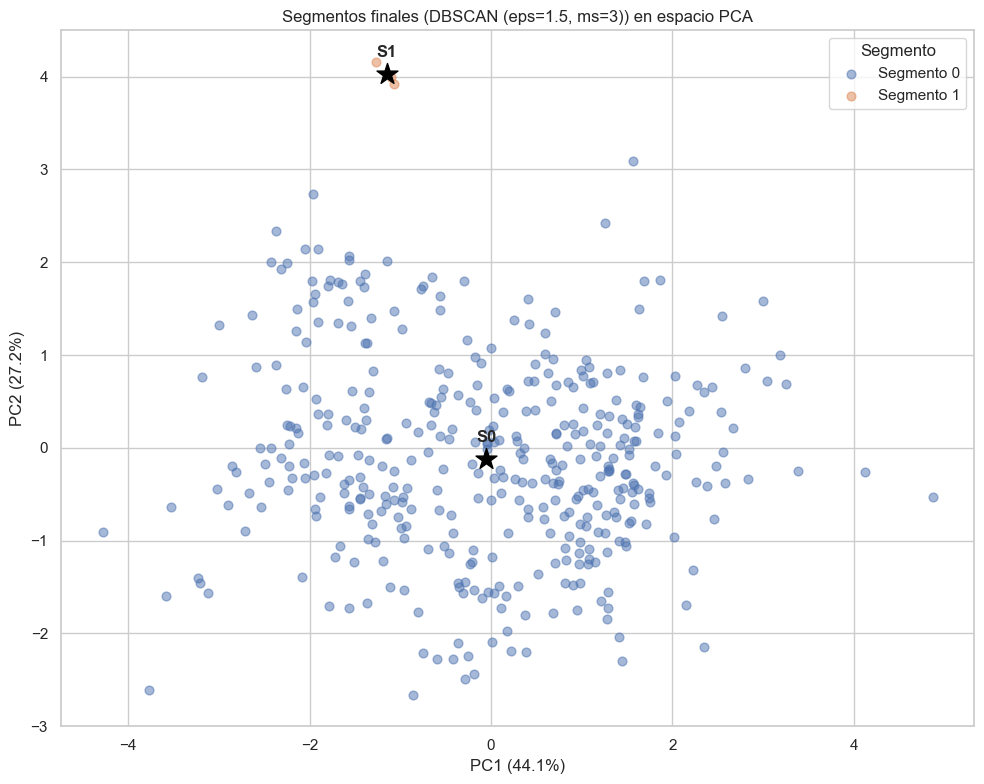

In [41]:
fig, ax = plt.subplots(figsize=(10, 8))

for seg in sorted(df_segmented["Segment"].unique()):
    mask = best_labels == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.5, s=40, label=f"Segmento {seg}")
    # Centroide
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, marker="*", s=250, c="black", zorder=5)
    ax.annotate(f"S{seg}", (cx, cy), fontsize=12, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 10),
                textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"Segmentos finales ({best_method}) en espacio PCA")
ax.legend(title="Segmento", loc="best")
plt.tight_layout()
plt.show()

---
## 7. Conclusiones

1. **PCA** redujo las 6 variables de gasto a 2 componentes principales que capturan la mayoría de la varianza. El biplot reveló que PC1 separa principalmente clientes con alto gasto en `Grocery/Milk/Detergents_Paper` (retail) de aquellos con alto gasto en `Fresh/Frozen` (horeca).

2. **K-Means** y **Clustering Aglomerativo** son los métodos más robustos para este dataset; ambos generan segmentos compactos y bien separados. **DBSCAN** es útil para detectar outliers pero su rendimiento depende fuertemente de los parámetros `eps` y `min_samples`.

3. El **Silhouette Score** guió la selección del número óptimo de clusters y la elección del mejor método.

4. El **post-procesamiento** permitió identificar segmentos con perfiles de gasto distintos, validados contra la variable `Channel` (Horeca vs Retail), confirmando que la segmentación descubierta tiene sentido de negocio.